In [1]:
# UR3 CobotOps : UR3 협동 로봇 운전 데이터 미니 프로젝트

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

In [5]:
pd.set_option('display.max_columns', None) # 전체 컬럼 보기 옵션

In [6]:
df = pd.read_excel('ur3_cobotops.xlsx')
df

,Num,Timestamp,Current_J0,Temperature_T0,Current_J1,Temperature_J1,Current_J2,Temperature_J2,Current_J3,Temperature_J3,Current_J4,Temperature_J4,Current_J5,Temperature_J5,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,Tool_current,cycle,Robot_ProtectiveStop,grip_lost
0,1,2022-10-26T08:17:21.847Z,0.109628,27.8750,-2.024669,29.3750,-1.531442,29.3750,-0.998570,32.1250,-0.062540,32.2500,-0.152622,32.0000,2.955651e-01,-0.000490,0.001310,-0.132836,-0.007479,-0.152962,0.082732,1,0.0,False
1,2,2022-10-26T08:17:22.852Z,0.595605,27.8750,-2.278456,29.3125,-0.866556,29.4375,-0.206097,32.1875,-1.062762,32.2500,-0.260764,32.0000,-7.391485e-30,-0.000304,0.002185,0.001668,-0.000767,0.000417,0.505895,1,0.0,False
2,3,2022-10-26T08:17:23.857Z,-0.229474,27.8750,-2.800408,29.3125,-2.304336,29.4375,-0.351499,32.1250,-0.668869,32.3125,0.039071,32.0625,1.369386e-01,0.007795,-2.535874,0.379867,0.000455,-0.496856,0.079420,1,0.0,False
3,4,2022-10-26T08:17:24.863Z,0.065053,27.8750,-3.687768,29.3125,-1.217652,29.4375,-1.209115,32.1250,-0.819755,32.2500,0.153903,32.0000,-9.030032e-02,-0.004911,-0.009096,-0.384196,0.018411,0.425559,0.083325,1,0.0,False
4,5,2022-10-26T08:17:25.877Z,0.884140,27.8750,-2.938830,29.3750,-1.794076,29.4375,-2.356471,32.1875,-0.966427,32.3125,0.178998,32.0000,1.268088e-01,0.005567,0.001138,-0.353284,0.014994,0.180989,0.086379,1,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7404,7405,2022-10-26T15:36:02.555Z,-0.109017,37.1875,-2.261695,40.3125,-1.082678,40.6875,-0.494714,43.3750,-0.019447,45.2500,0.023025,44.5625,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.080013,264,0.0,False
7405,7406,2022-10-26T15:36:03.562Z,-0.098536,37.1875,-2.251992,40.3125,-1.094420,40.6875,-0.515789,43.3750,-0.009186,45.2500,0.047794,44.5000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.078740,264,0.0,False
7406,7407,2022-10-26T15:36:04.571Z,-0.121100,37.1875,-2.280791,40.2500,-1.121319,40.6875,-0.502406,43.3750,-0.002978,45.2500,0.028567,44.5000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.091471,264,0.0,False
7407,7408,2022-10-26T15:36:05.572Z,-0.129370,37.1875,-2.269061,40.3125,-1.091610,40.6250,-0.491158,43.3750,-0.001136,45.2500,0.049641,44.5625,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.090026,264,0.0,False


In [7]:
df.columns

Index(['Num', 'Timestamp', 'Current_J0', 'Temperature_T0', 'Current_J1',
       'Temperature_J1', 'Current_J2', 'Temperature_J2', 'Current_J3',
       'Temperature_J3', 'Current_J4', 'Temperature_J4', 'Current_J5',
       'Temperature_J5', 'Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3',
       'Speed_J4', 'Speed_J5', 'Tool_current', 'cycle ',
       'Robot_ProtectiveStop', 'grip_lost'],
      dtype='str')

In [8]:
df.columns = df.columns.str.strip() # 컬럼의 공백 제거
# df.columns = df.columns.str.strip().lower() # 컬럼의 공백 제거후 전부 소문자로 변경

In [9]:
df.columns

Index(['Num', 'Timestamp', 'Current_J0', 'Temperature_T0', 'Current_J1',
       'Temperature_J1', 'Current_J2', 'Temperature_J2', 'Current_J3',
       'Temperature_J3', 'Current_J4', 'Temperature_J4', 'Current_J5',
       'Temperature_J5', 'Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3',
       'Speed_J4', 'Speed_J5', 'Tool_current', 'cycle', 'Robot_ProtectiveStop',
       'grip_lost'],
      dtype='str')

In [10]:
df.shape

(7409, 24)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7409 entries, 0 to 7408
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Num                   7409 non-null   int64  
 1   Timestamp             7409 non-null   str    
 2   Current_J0            7363 non-null   float64
 3   Temperature_T0        7355 non-null   float64
 4   Current_J1            7355 non-null   float64
 5   Temperature_J1        7355 non-null   float64
 6   Current_J2            7355 non-null   float64
 7   Temperature_J2        7355 non-null   float64
 8   Current_J3            7355 non-null   float64
 9   Temperature_J3        7355 non-null   float64
 10  Current_J4            7355 non-null   float64
 11  Temperature_J4        7355 non-null   float64
 12  Current_J5            7355 non-null   float64
 13  Temperature_J5        7355 non-null   float64
 14  Speed_J0              7355 non-null   float64
 15  Speed_J1              7355 non-n

In [12]:
df.isnull().sum()

Num                      0
Timestamp                0
Current_J0              46
Temperature_T0          54
Current_J1              54
Temperature_J1          54
Current_J2              54
Temperature_J2          54
Current_J3              54
Temperature_J3          54
Current_J4              54
Temperature_J4          54
Current_J5              54
Temperature_J5          54
Speed_J0                54
Speed_J1                54
Speed_J2                54
Speed_J3                54
Speed_J4                54
Speed_J5                54
Tool_current            54
cycle                    0
Robot_ProtectiveStop    54
grip_lost                0
dtype: int64

In [13]:
df['Robot_ProtectiveStop'].value_counts()

Robot_ProtectiveStop
0.0    7077
1.0     278
Name: count, dtype: int64

In [14]:
df['Robot_ProtectiveStop'].value_counts(normalize=True)

Robot_ProtectiveStop
0.0    0.962203
1.0    0.037797
Name: proportion, dtype: float64

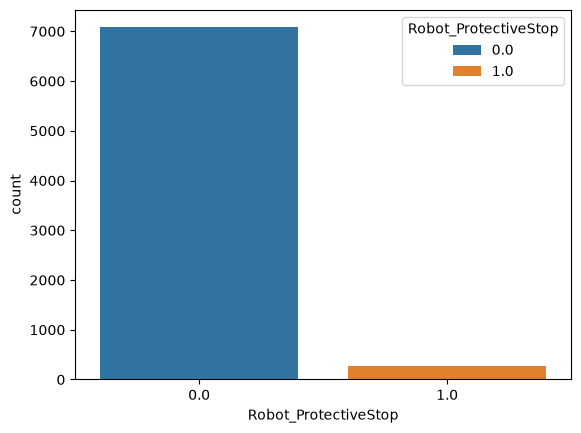

In [15]:
sns.countplot(data=df, x='Robot_ProtectiveStop', hue='Robot_ProtectiveStop')
plt.show()

In [16]:
# 정상 / 정지 상태 센서 비교
compare_cols = [
    "Current_J0", "Current_J1", "Temperature_T0", "Temperature_J1",
    "Speed_J0", "Speed_J1", "Tool_current"
]
df.groupby("Robot_ProtectiveStop")[compare_cols].mean()

,Current_J0,Current_J1,Temperature_T0,Temperature_J1,Speed_J0,Speed_J1,Tool_current
Robot_ProtectiveStop,,,,,,,
0.0,-0.053051,-2.280707,34.874638,37.621971,0.001930,-0.000471,0.110356
1.0,0.025680,-2.736537,35.725045,38.618480,-0.004933,0.013606,0.088440


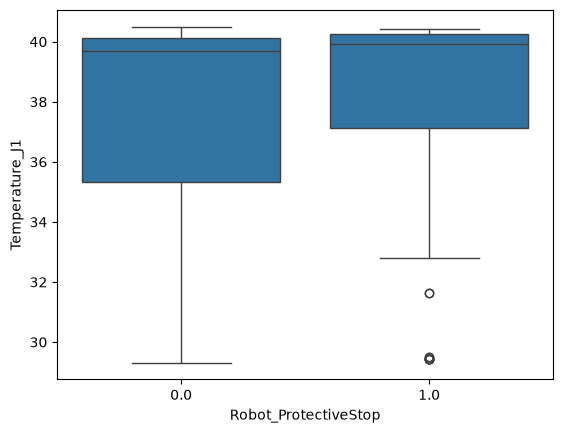

In [17]:
sns.boxplot(data=df, x="Robot_ProtectiveStop", y="Temperature_J1")
plt.show()

In [18]:
# 파생 변수 : 평균
current_cols = [ "Current_J0", "Current_J1", "Current_J2", "Current_J3", "Current_J4",
                 "Current_J5" ]
temperature_cols = [ "Temperature_T0", "Temperature_J1", "Temperature_J2", 
                     "Temperature_J3", "Temperature_J4", "Temperature_J5" ]
speed_cols = [ "Speed_J0", "Speed_J1", "Speed_J2", "Speed_J3", "Speed_J4", "Speed_J5" ]

df['avg_current'] = df[current_cols].mean(axis=1) # axis=1은 가로로 계산
df['avg_temperature'] = df[temperature_cols].mean(axis=1)
df['avg_speed'] = df[speed_cols].mean(axis=1)
df

,Num,Timestamp,Current_J0,Temperature_T0,Current_J1,Temperature_J1,Current_J2,Temperature_J2,Current_J3,Temperature_J3,Current_J4,Temperature_J4,Current_J5,Temperature_J5,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,Tool_current,cycle,Robot_ProtectiveStop,grip_lost,avg_current,avg_temperature,avg_speed
0,1,2022-10-26T08:17:21.847Z,0.109628,27.8750,-2.024669,29.3750,-1.531442,29.3750,-0.998570,32.1250,-0.062540,32.2500,-0.152622,32.0000,2.955651e-01,-0.000490,0.001310,-0.132836,-0.007479,-0.152962,0.082732,1,0.0,False,-0.776702,30.500000,0.000518
1,2,2022-10-26T08:17:22.852Z,0.595605,27.8750,-2.278456,29.3125,-0.866556,29.4375,-0.206097,32.1875,-1.062762,32.2500,-0.260764,32.0000,-7.391485e-30,-0.000304,0.002185,0.001668,-0.000767,0.000417,0.505895,1,0.0,False,-0.679838,30.510417,0.000533
2,3,2022-10-26T08:17:23.857Z,-0.229474,27.8750,-2.800408,29.3125,-2.304336,29.4375,-0.351499,32.1250,-0.668869,32.3125,0.039071,32.0625,1.369386e-01,0.007795,-2.535874,0.379867,0.000455,-0.496856,0.079420,1,0.0,False,-1.052586,30.520833,-0.417946
3,4,2022-10-26T08:17:24.863Z,0.065053,27.8750,-3.687768,29.3125,-1.217652,29.4375,-1.209115,32.1250,-0.819755,32.2500,0.153903,32.0000,-9.030032e-02,-0.004911,-0.009096,-0.384196,0.018411,0.425559,0.083325,1,0.0,False,-1.119222,30.500000,-0.007422
4,5,2022-10-26T08:17:25.877Z,0.884140,27.8750,-2.938830,29.3750,-1.794076,29.4375,-2.356471,32.1875,-0.966427,32.3125,0.178998,32.0000,1.268088e-01,0.005567,0.001138,-0.353284,0.014994,0.180989,0.086379,1,0.0,False,-1.165444,30.531250,-0.003965
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7404,7405,2022-10-26T15:36:02.555Z,-0.109017,37.1875,-2.261695,40.3125,-1.082678,40.6875,-0.494714,43.3750,-0.019447,45.2500,0.023025,44.5625,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.080013,264,0.0,False,-0.657421,41.895833,0.000000
7405,7406,2022-10-26T15:36:03.562Z,-0.098536,37.1875,-2.251992,40.3125,-1.094420,40.6875,-0.515789,43.3750,-0.009186,45.2500,0.047794,44.5000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.078740,264,0.0,False,-0.653688,41.885417,0.000000
7406,7407,2022-10-26T15:36:04.571Z,-0.121100,37.1875,-2.280791,40.2500,-1.121319,40.6875,-0.502406,43.3750,-0.002978,45.2500,0.028567,44.5000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.091471,264,0.0,False,-0.666671,41.875000,0.000000
7407,7408,2022-10-26T15:36:05.572Z,-0.129370,37.1875,-2.269061,40.3125,-1.091610,40.6250,-0.491158,43.3750,-0.001136,45.2500,0.049641,44.5625,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.090026,264,0.0,False,-0.655449,41.885417,0.000000


In [19]:
display(
    df.groupby("Robot_ProtectiveStop")[['avg_current', 'avg_temperature', 'avg_speed']]
    .mean()
    .round(3)
)

,avg_current,avg_temperature,avg_speed
Robot_ProtectiveStop,,,
0.0,-0.690,39.307,0.000
1.0,-0.835,40.297,0.003


In [20]:
# Timestamp 변환, 글자(str) ==> 날짜/시간으로 변경
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

In [21]:
df.info() # Timestamp             6546 non-null   datetime64[us, UTC]

<class 'pandas.DataFrame'>
RangeIndex: 7409 entries, 0 to 7408
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   Num                   7409 non-null   int64              
 1   Timestamp             6546 non-null   datetime64[us, UTC]
 2   Current_J0            7363 non-null   float64            
 3   Temperature_T0        7355 non-null   float64            
 4   Current_J1            7355 non-null   float64            
 5   Temperature_J1        7355 non-null   float64            
 6   Current_J2            7355 non-null   float64            
 7   Temperature_J2        7355 non-null   float64            
 8   Current_J3            7355 non-null   float64            
 9   Temperature_J3        7355 non-null   float64            
 10  Current_J4            7355 non-null   float64            
 11  Temperature_J4        7355 non-null   float64            
 12  Current_J5       

In [22]:
# 정답이 없는 행 삭제
df_clean = df.dropna(subset=['Robot_ProtectiveStop']).copy() # 복사본을 넘긴다
df_clean['Robot_ProtectiveStop'] = df_clean['Robot_ProtectiveStop'].astype(int) # 정수로

In [23]:
df_clean.isnull().sum()

Num                       0
Timestamp               855
Current_J0                0
Temperature_T0            0
Current_J1                0
Temperature_J1            0
Current_J2                0
Temperature_J2            0
Current_J3                0
Temperature_J3            0
Current_J4                0
Temperature_J4            0
Current_J5                0
Temperature_J5            0
Speed_J0                  0
Speed_J1                  0
Speed_J2                  0
Speed_J3                  0
Speed_J4                  0
Speed_J5                  0
Tool_current              0
cycle                     0
Robot_ProtectiveStop      0
grip_lost                 0
avg_current               0
avg_temperature           0
avg_speed                 0
dtype: int64

In [24]:
df_clean.to_csv('ur3_cobotops_ok.csv', index=False, encoding='utf-8-sig') # 저장

In [25]:
df2 = pd.read_csv('ur3_cobotops_ok.csv') # 확인
df2

,Num,Timestamp,Current_J0,Temperature_T0,Current_J1,Temperature_J1,Current_J2,Temperature_J2,Current_J3,Temperature_J3,Current_J4,Temperature_J4,Current_J5,Temperature_J5,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,Tool_current,cycle,Robot_ProtectiveStop,grip_lost,avg_current,avg_temperature,avg_speed
0,1,2022-10-26 08:17:21.847000+00:00,0.109628,27.8750,-2.024669,29.3750,-1.531442,29.3750,-0.998570,32.1250,-0.062540,32.2500,-0.152622,32.0000,2.955651e-01,-0.000490,0.001310,-0.132836,-0.007479,-0.152962,0.082732,1,0,False,-0.776702,30.500000,0.000518
1,2,2022-10-26 08:17:22.852000+00:00,0.595605,27.8750,-2.278456,29.3125,-0.866556,29.4375,-0.206097,32.1875,-1.062762,32.2500,-0.260764,32.0000,-7.391485e-30,-0.000304,0.002185,0.001668,-0.000767,0.000417,0.505895,1,0,False,-0.679838,30.510417,0.000533
2,3,2022-10-26 08:17:23.857000+00:00,-0.229474,27.8750,-2.800408,29.3125,-2.304336,29.4375,-0.351499,32.1250,-0.668869,32.3125,0.039071,32.0625,1.369386e-01,0.007795,-2.535874,0.379867,0.000455,-0.496856,0.079420,1,0,False,-1.052586,30.520833,-0.417946
3,4,2022-10-26 08:17:24.863000+00:00,0.065053,27.8750,-3.687768,29.3125,-1.217652,29.4375,-1.209115,32.1250,-0.819755,32.2500,0.153903,32.0000,-9.030032e-02,-0.004911,-0.009096,-0.384196,0.018411,0.425559,0.083325,1,0,False,-1.119222,30.500000,-0.007422
4,5,2022-10-26 08:17:25.877000+00:00,0.884140,27.8750,-2.938830,29.3750,-1.794076,29.4375,-2.356471,32.1875,-0.966427,32.3125,0.178998,32.0000,1.268088e-01,0.005567,0.001138,-0.353284,0.014994,0.180989,0.086379,1,0,False,-1.165444,30.531250,-0.003965
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7350,7405,2022-10-26 15:36:02.555000+00:00,-0.109017,37.1875,-2.261695,40.3125,-1.082678,40.6875,-0.494714,43.3750,-0.019447,45.2500,0.023025,44.5625,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.080013,264,0,False,-0.657421,41.895833,0.000000
7351,7406,2022-10-26 15:36:03.562000+00:00,-0.098536,37.1875,-2.251992,40.3125,-1.094420,40.6875,-0.515789,43.3750,-0.009186,45.2500,0.047794,44.5000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.078740,264,0,False,-0.653688,41.885417,0.000000
7352,7407,2022-10-26 15:36:04.571000+00:00,-0.121100,37.1875,-2.280791,40.2500,-1.121319,40.6875,-0.502406,43.3750,-0.002978,45.2500,0.028567,44.5000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.091471,264,0,False,-0.666671,41.875000,0.000000
7353,7408,2022-10-26 15:36:05.572000+00:00,-0.129370,37.1875,-2.269061,40.3125,-1.091610,40.6250,-0.491158,43.3750,-0.001136,45.2500,0.049641,44.5625,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.090026,264,0,False,-0.655449,41.885417,0.000000


In [26]:
# 데이터(X)와 정답(y)를 준비한다.

In [27]:
drop_cols = [ 'Num', 'Timestamp', 'cycle', 'grip_lost', 'Robot_ProtectiveStop' ]
X = df_clean.drop(columns=drop_cols)
y = df_clean['Robot_ProtectiveStop']

In [28]:
X.shape

(7355, 22)

In [29]:
y.shape

(7355,)

In [30]:
# ML 코딩 5단계
# 1. 훈련 데이터와 테스트 데이터로 나눈다. train_test_split 함수 사용
# 2. ML 알고리즘을 선택. model = DecisionTreeClassifier(...)
# 3. 훈련. model.fit(...)
# 4. 평가. model.score(...)
# 5. 새로운 데이터로 예측. model.predict(...)

In [31]:
# 훈련 데이터 / 테스트 데이터로 나눈다
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                            random_state=42, stratify=y)

In [32]:
# 결측치 처리 : X_train의 중앙값 채우기
median = X_train.median()
X_train = X_train.fillna(median)
X_test = X_test.fillna(median)

In [33]:
model = DecisionTreeClassifier(max_depth=4, min_samples_split=20,
                               class_weight='balanced', random_state=42)

In [34]:
from sklearn import set_config

# 모델을 HTML 그림이 아닌 일반 텍스트로 출력
set_config(display='text')

In [35]:
model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=4,
                       min_samples_split=20, random_state=42)

In [36]:
y_pred = model.predict(X_test) # X_test를 가지고 예측한 값, 예측한_정답

In [37]:
# 모델 평가
baseline = y_test.value_counts(normalize=True).max() # 기준점(모두 정상)을 예측
accuracy = accuracy_score(y_test, y_pred) # 모델의 점수
balanced_acc = balanced_accuracy_score(y_test, y_pred) # 불균형 데이터 기준 점수

print(f"기준점(모두 정상)을 예측한 점수: {baseline:.2%}")
print(f"모델의 점수: {accuracy:.2%}")
print(f"balanced accuracy 점수: {balanced_acc:.2%}")

기준점(모두 정상)을 예측한 점수: 96.19%
모델의 점수: 73.28%
balanced accuracy 점수: 79.25%


In [38]:
print( 
    classification_report(y_test, y_pred, target_names=['Normal', 'Protective Stop'],
                     zero_division=0)
)

                 precision    recall  f1-score   support

         Normal       0.99      0.73      0.84      1415
Protective Stop       0.11      0.86      0.20        56

       accuracy                           0.73      1471
      macro avg       0.55      0.79      0.52      1471
   weighted avg       0.96      0.73      0.82      1471



In [39]:
# 혼동행렬
cm = confusion_matrix(y_test, y_pred)
cm

array([[1030,  385],
       [   8,   48]], dtype=int64)

In [40]:
cm_df = pd.DataFrame(cm, index=['Actual Normal', 'Actual Stop'],
                    columns=['Pred Normal', 'Pred Stop'])
cm_df

,Pred Normal,Pred Stop
Actual Normal,1030,385
Actual Stop,8,48


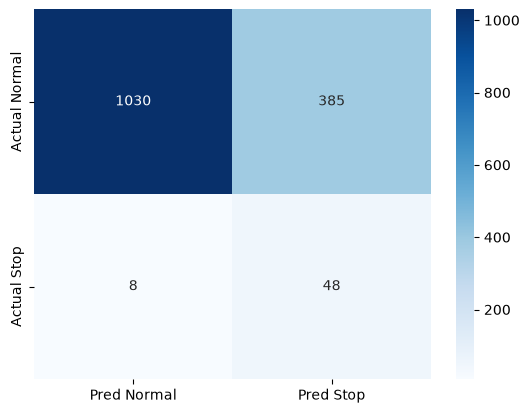

In [41]:
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.show()

In [42]:
# 아래 Confusion Matrix 이미지 참조

<div align="left">
    <img src="https://github.com/sungback/DS01/blob/main/work/confusion_matrix_pregnant.png?raw=true" width="70%">
</div>

In [44]:
# 과학 표기법 --> 일반 표기법
pd.options.display.float_format = '{:.2f}'.format

In [47]:
# 변수 중요도 확인
imp = pd.DataFrame( {"feature":X.columns, "importance":model.feature_importances_} )
imp = imp.sort_values("importance", ascending=False)
imp.head(10)

,feature,importance
19,avg_current,0.41
15,Speed_J3,0.19
17,Speed_J5,0.14
18,Tool_current,0.10
10,Current_J5,0.07
5,Temperature_J2,0.07
6,Current_J3,0.03
12,Speed_J0,0.00
0,Current_J0,0.00
13,Speed_J1,0.00


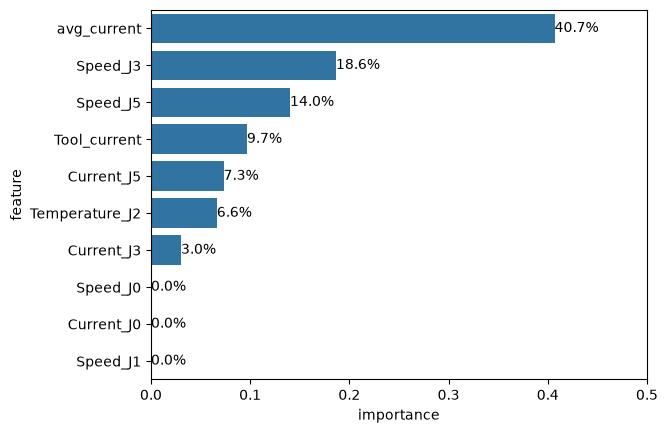

In [51]:
ax = sns.barplot(data=imp.head(10), x="importance", y="feature")
for i in ax.containers:
    ax.bar_label(i, fmt="{:.1%}")
plt.xlim(0, 0.5)
plt.show()

In [52]:
# end